# Social Media Analytics Pipeline - Phase 1 
## Data Ingestion + AI Sentiment Analysis
**Phase:** 1 of 4 - Load, Clean, Reformat, Enrich, AI Sentiment  
**Output:** social_analytics.db - SQLite databse for Phase 2 (SQL) and Phase 3 (Power BI)

---
### What this notebook does 
| Step | Task | Tool |
|------|------|------|
| 1 | Install & import libraries | pip, pandas, sqlite3|
| 2 | Load & inspect CSV dataset | pandas |
| 3 | Clean & enrich data | pandas , numpy |
| 4 | AI sentiment analysis on captions | HuggingFace Transformers (RoBERTa) |
| 5 | Save to SQLite database | sqlite3 |
| 6| Visualize results | matplotlib, seaborn |


### Step 1 - Install & Import Libraries


In [1]:
# Install required libraries (run once — comment out after first run)
#!pip install pandas transformers torch scipy matplotlib seaborn

import sqlite3
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

warnings.filterwarnings("ignore")

print("Libraries loaded successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully
   pandas  2.3.2
   numpy   2.3.3


In [4]:
# !pip install pandas transformers scipy matplotlib seaborn
# !python -m pip install --upgrade pip

### Step 2 - Load & Inspect the CSV Dataset

In [5]:
csv_file = "social_media_engagement_dataset.csv"
DB_FILE = "social_media_analytics.db"
table_name = "social_media_posts"

# load csv
df_raw = pd.read_csv(csv_file)

print(f" Load: {len(df_raw):,} rows x {len(df_raw.columns)} columns")
print(f" File size : {os.path.getsize(csv_file)/1024:.1f} KB")
print(f"\n Columns: \n {list(df_raw.columns)}")

 Load: 5,000 rows x 20 columns
 File size : 650.2 KB

 Columns: 
 ['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified']


In [6]:
# preview first 5 rows
df_raw.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


In [7]:
# Data types and null counts
print(" Column info: ")
info_df = pd.DataFrame({
    "dtpype" : df_raw.dtypes,
    "nulls"  : df_raw.isnull().sum(),
    "null_%" : (df_raw.isnull().sum()/len(df_raw)*100).round(1),
    "sample" : [df_raw[c].dropna().iloc[0] if len(df_raw[c].dropna()) else "-" for c in df_raw.columns]
})
display(info_df)

 Column info: 


,dtpype,nulls,null_%,sample
Post_ID,object,0,0.0,POST_04552
Timestamp,object,0,0.0,2024-01-01 01:42:00
Platform,object,0,0.0,Instagram
Content_Type,object,0,0.0,Carousel
Category,object,0,0.0,Business
Likes,int64,0,0.0,8287
Comments,int64,0,0.0,247
Shares,int64,0,0.0,51
Views,int64,0,0.0,29502
Saves,int64,0,0.0,20


### Step 3 - Clean & Enrich the Data
This step: 
- Standardize columns name to match our schema
- Fills missings values
- Calculates "engagement_rate = likes/views"
- Add "franchise_group" and "release_phase" columns (key for entertaiment analytics)

In [8]:
# copy the dataset
df = df_raw.copy()

# standardize column names to "abc_xyx"
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(r"[\s\-/]+","_",regex=True)
)

print(f"\n Columns: \n {list(df.columns)}")
# Map raw data column name variants to our schema
rename_map = {
    "post_id": "post_id",
    "timestamp": "timestamp",
    "platform": "platform",
    "content_type" : "content_type",
    "category": "category",
    "likes": "likes",
    "comments": "comments",
    "shares": "shares",
    "views": "views",
    "saves":"saves",
    "follower_count":"followers",
    "engagement_rate": "engagement_rate",
    "hour": "hour_of_day",
    "date": "day_of_week",
    "hashtag": "hashtag_count", 
    "content_lenghth":"content_length",
    "sentiment":"sentiment",
    "influencer_tier":"influencer",
    "has_media": "has_media",
    "verified": "is_verified"
}

df = df.rename(columns = {k: v for k, v in rename_map.items() if k in df.columns})

print(" Column after rename: ")
print(f" {list(df.columns)}")


 Columns: 
 ['post_id', 'timestamp', 'platform', 'content_type', 'category', 'likes', 'comments', 'shares', 'views', 'saves', 'follower_count', 'engagement_rate', 'hour_of_day', 'day_of_week', 'hashtag_count', 'content_length', 'sentiment', 'influencer_tier', 'has_media', 'is_verified']
 Column after rename: 
 ['post_id', 'timestamp', 'platform', 'content_type', 'category', 'likes', 'comments', 'shares', 'views', 'saves', 'followers', 'engagement_rate', 'hour_of_day', 'day_of_week', 'hashtag_count', 'content_length', 'sentiment', 'influencer', 'has_media', 'is_verified']


In [9]:
# numeric columns 
numeric_cols = ['likes', 'comments', 'shares', 'views', 'saves', 'followers', 
              'engagement_rate', 'hour_of_day', 'hashtag_count', 'content_length']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# res = list(dict.fromkeys(df["category"]))
# print(res)

# --------- caption -----------------------
if "caption" not in df.columns:
    df["caption"] = ""
    print(" No caption column found - sentiment will default to neutral")
# ---------- parse dates -----------------
if "post_date" in df.columns:
    df["post_date"] = pd.to_datetime(df["post_date"], errors = "coerce")
    df["post_date_str"] = df["post_date"].dt.strftime("%Y-%m-%d")
    df["post_month"] = df["post_date"].dt.to_period("M").astype(str)
    df["post_weekday"] = df["post_date"].dt.day_name()
else:
    df["post_date_str"] = "2026-01-01"
    df["post_month"] = "2026-01"
    df["post_weekday"] = "Unknown"



 No caption column found - sentiment will default to neutral


In [10]:
# Franchise group or entertainment context

def get_franchise_group(category):
    if category in ("Entertainment", "Gaming"):
        return "Entertainment & Gaming"
    elif category in ("Sports", "Fitness"):
        return "Sports & Fitness"
    elif category in ("Lifestyle", "Fashion", "Travel"):
        return "Lifestyle & Culture"
    elif category in ("Food", "Health"):
        return "Health & Wellness"
    elif category in ("Technology", "Business"):
        return "Tech & Business"
    elif category == "Education":
        return "Education & Learning"
    else:
        return "Uncategorized"           # catches nulls or unexpected values

df["franchise_group"] = df["category"].apply(get_franchise_group)

# Verify
print("Franchise groups assigned:")
print(df["franchise_group"].value_counts())
print(f"\n  Uncategorized rows: {(df['franchise_group'] == 'Uncategorised').sum()}")


Franchise groups assigned:
franchise_group
Lifestyle & Culture       1259
Entertainment & Gaming     908
Tech & Business            816
Health & Wellness          810
Sports & Fitness           794
Education & Learning       413
Name: count, dtype: int64

  Uncategorized rows: 0


In [11]:
print(f"\n Clean dataset: {len(df):,} rows x {len(df.columns)} columns ")
df.head()


 Clean dataset: 5,000 rows x 25 columns 


,post_id,timestamp,platform,content_type,category,likes,comments,shares,views,saves,...,content_length,sentiment,influencer,has_media,is_verified,caption,post_date_str,post_month,post_weekday,franchise_group
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,...,985,Positive,Macro,True,False,,2026-01-01,2026-01,Unknown,Tech & Business
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,...,627,Negative,Macro,False,True,,2026-01-01,2026-01,Unknown,Health & Wellness
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,...,79,Positive,Macro,True,True,,2026-01-01,2026-01,Unknown,Health & Wellness
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,...,554,Neutral,Macro,True,False,,2026-01-01,2026-01,Unknown,Sports & Fitness
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,...,1136,Positive,Mid-tier,True,False,,2026-01-01,2026-01,Unknown,Sports & Fitness


In [12]:
# Stats check
print("Engagement rate: ")
print(df["engagement_rate"].describe().to_frame().T.round(2))

print("\n Post by Platform")
display(df["platform"].value_counts().to_frame())

Engagement rate: 
                  count   mean    std  min  25%  50%  75%     max
engagement_rate  5000.0  11.47  71.46  0.0  1.0  2.0  6.0  3510.0

 Post by Platform


,count
platform,
Instagram,1283
Twitter,994
Facebook,984
TikTok,758
LinkedIn,502
YouTube,479


## Step 4 - Sentiment analysis 

https://huggingface.co/blog/sentiment-analysis-python



In [13]:
# Use Hugging face to add a new sentiment analysis


### Sentiment anaylysis 
Using the given data


In [14]:
# Preview results
print("Sample sentiment restuls: ")
display(
    df[["content_type","sentiment"]].sample(8,random_state = 42).reset_index(drop=True)
)

Sample sentiment restuls: 


,content_type,sentiment
0,Reel,Neutral
1,Live,Positive
2,Stitch,Positive
3,Poll,Positive
4,Story,Neutral
5,Reel,Positive
6,Retweet,Positive
7,Duet,Negative


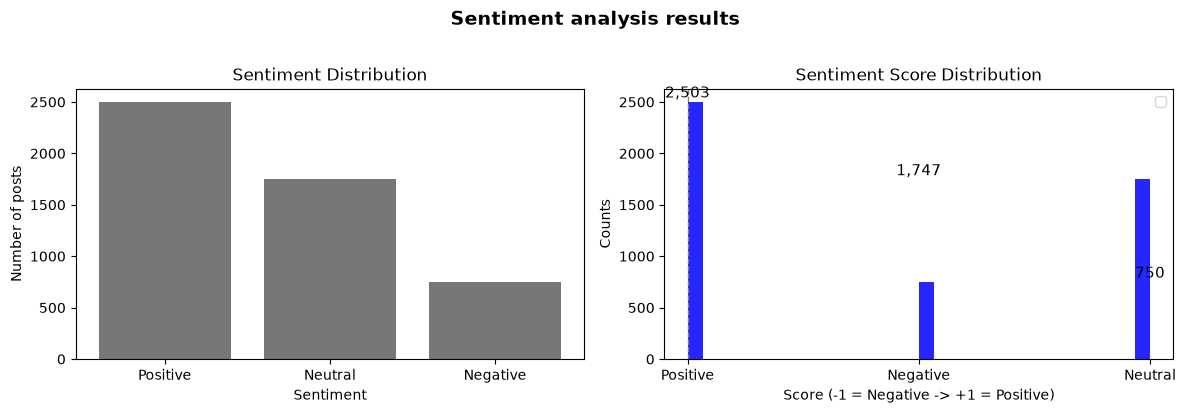

Chart save: sentiment_distribution.png


In [15]:
# Sentiment distribution chart 
fig, axes = plt.subplots(1, 2, figsize=(12,4))
fig.suptitle("Sentiment analysis results", fontsize = 14, fontweight = "bold", y = 1.02)

# Bar chart - counts
colors = {"positive": "#4CAF50", "neutral": "#9E9E9E", "negative": "#F44336"}
dist = df["sentiment"].value_counts()
bars = axes[0].bar(dist.index,dist.values,
                  color = [colors.get(l, "#777") for l in dist.index], linewidth = 1.2)

axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of posts")

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{bar.get_height():,}",ha = "center", va ="bottom", fontsize = 11)


# Sentiment score distribution
axes[1].hist(df["sentiment"], bins = 30, color = "blue",linewidth = 0.5, alpha = 0.85)
axes[1].axvline(0,color = "gray", linestyle = "--",linewidth = 1)
axes[1].set_title("Sentiment Score Distribution")
axes[1].set_xlabel("Score (-1 = Negative -> +1 = Positive)")
axes[1].set_ylabel("Counts")
axes[1].legend()

plt.tight_layout()
plt.savefig("sentiment_distribution.png")
plt.show()
print("Chart save: sentiment_distribution.png")

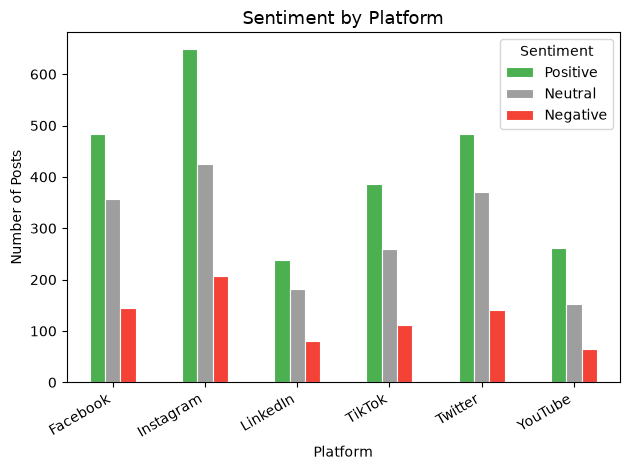

In [19]:
# Sentiment analysis breakdown by category

pivot = (
    df.groupby(["platform","sentiment"])
        .size()
        .unstack(fill_value = 0)
        .reindex(columns = ["Positive", "Neutral", "Negative"], fill_value = 0)
)

  
bars = pivot.plot(
        kind = "bar", 
        color = ["#4CAF50","#9E9E9E","#F44336"],
        edgecolor = "white",
        linewidth=0.8)
plt.title("Sentiment by Platform", fontsize = 13)
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.xticks(rotation=30,ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("sentiment_analysis_by_platform.png")
plt.show()

### Step 5: Save to SQLite Database
The cleaned and enriched data is saved to `social_analytics.db`.
This file is a single source of truth for:
- Phase 2: SQL queries & Boolean search filters
 - Phase 3: Power BI dashboard 

In [20]:
# Final column order
final_cols = ['post_id', 'timestamp', 'platform', 'content_type', 'category', 
              'likes', 'comments', 'shares', 'views', 'saves', 'followers', 
              'engagement_rate', 'hour_of_day', 'day_of_week', 'hashtag_count',
              'content_length', 'sentiment', 'influencer', 'has_media', 'is_verified']
cols_to_save = [c for c in final_cols if c in df.columns]
extra_cols = [c for c in df.columns if c not in cols_to_save
              and c not in ("post_date",) ]
cols_to_save += extra_cols

df_out = df[cols_to_save].rename(columns={"timestamp":"post_date"})


# Save to SQLite
connection = sqlite3.connect(DB_FILE)
cursor_obj  = connection.cursor()

cursor_obj.execute(f"DROP TABLE IF EXISTS {table_name}")
df_out.to_sql(table_name, connection, index =False, if_exists = "replace")

for idx_sql in [
    f"CREATE INDEX IF NOT EXISTS idx_platform ON {table_name}(platform)",
    f"CREATE INDEX IF NOT EXISTS idx_date ON {table_name}(post_date)",
    f"CREATE INDEX IF NOT EXISTS idx_sentiment ON {table_name}(sentiment)",
    f"CREATE INDEX IF NOT EXISTS idx_likes ON {table_name}(likes)",
]:
    cursor_obj.execute(idx_sql)


connection.commit()
row_count = cursor_obj.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
col_count = len(cursor_obj.execute(f"PRAGMA table_info({table_name})").fetchall())
db_size = os.path.getsize(DB_FILE)/1024

connection.close()
print(f"Datbase save: {DB_FILE}")
print(f" Rows: {row_count:,}")
print(f" Columns: {row_count:,}")




Datbase save: social_media_analytics.db
 Rows: 5,000
 Columns: 5,000


### Step 6 - Exploratory Visualization
Quick chart to verify data and spot quality and spot patterns 


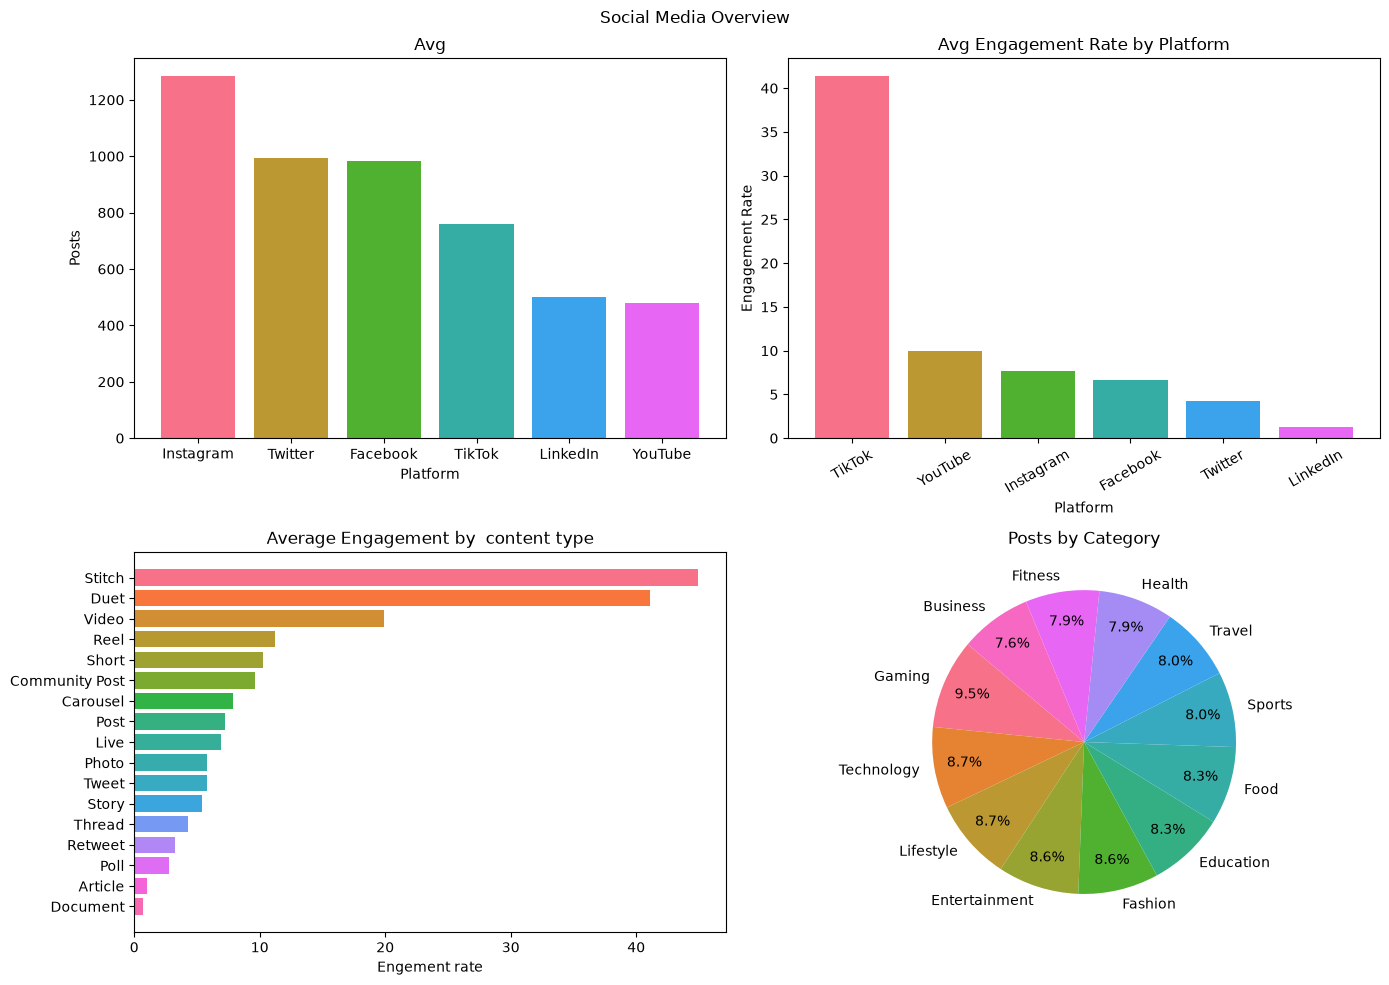

In [21]:
fig, axes = plt.subplots(2,2, figsize = (14,10))
fig.suptitle("Social Media Overview")

# engagement by platform
engagement_platform = df.groupby("platform")["engagement_rate"].mean().sort_values(ascending = False)
axes[0,1].bar(engagement_platform.index, engagement_platform.values,
             color = sns.color_palette("husl", len(engagement_platform)))
axes[0,1].set_title("Avg Engagement Rate by Platform")
axes[0,1].set_xlabel("Platform")
axes[0,1].set_ylabel("Engagement Rate")
axes[0,1].tick_params(axis = 'x',rotation=30)

# likes by category
category_counts = df["platform"].value_counts()
axes[0,0].bar(category_counts.index, category_counts.values,
             color = sns.color_palette("husl", len(category_counts)))
axes[0,0].set_title("Avg")
axes[0,0].set_xlabel("Platform")
axes[0,0].set_ylabel("Posts")

# Engagement rate by content type
if "content_type" in df.columns:
    engagement_type = df.groupby("content_type")["engagement_rate"].mean().sort_values(ascending=False)
    axes[1,0].barh(engagement_type.index, engagement_type.values,
                  color = sns.color_palette("husl",len(engagement_type)))
    axes[1,0].set_title("Average Engagement by  content type")
    axes[1,0].invert_yaxis()
    axes[1,0].set_xlabel("Engement rate")

# Posts by release phase  
category_cnt   = df["category"].value_counts()
category_label = category_cnt.index.tolist() 
colors = sns.color_palette("husl", len(category_label))

axes[1,1].pie(
    category_cnt.values,
    labels     = category_label,
    autopct    = "%1.1f%%",
    colors     = colors,
    startangle = 140,
    pctdistance= 0.8,             # moves % text slightly inward
)
axes[1,1].set_title("Posts by Category")
plt.tight_layout()
plt.show()



    
                      


In [22]:
# Verify database with a live SQL query
connection = sqlite3.connect(DB_FILE)
query = f"""
    SELECT
        platform,
        COUNT(*) AS total_post,
        ROUND(AVG(engagement_rate),2) AS avg_engagement_pct,
        SUM(likes) AS total_likes,
        SUM(shares) AS total_share
    FROM {table_name}
    GROUP BY platform
    ORDER BY avg_engagement_pct DESC
"""
result = pd.read_sql_query(query,connection)
connection.close()
display(result)

,platform,total_post,avg_engagement_pct,total_likes,total_share
0,TikTok,758,41.34,19556373,1894915
1,YouTube,479,9.95,4778847,470373
2,Instagram,1283,7.64,6342290,193680
3,Facebook,984,6.67,4081807,486593
4,Twitter,994,4.26,2405120,1001785
5,LinkedIn,502,1.31,519755,128821
